# Setup

In [1]:
import geopandas as gpd
import os

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from dotenv import load_dotenv

from utils import CensusDataLoader, ERSDataLoader

load_dotenv()

True

## Data Processing

### Data Collection

The majority of data processing takes place in the `RSS-Processing.py` script. 

It uses the ACS and ERS data loader classes from `./utils` to collect the needed ACS and ERS data (RUCC codes). 2013, 2018, and 2023 data is loaded in from the ACS and Vira Institute data. The PyGRIS library is used to get the census's county polygon data. 

The Vira Institute data provides longitude and latitude point coordinates so a spatial join merges the data by matching counties with facilities located inside of them. RUCC, ACS, and the geometry data all have GEOID columns so those are simple merges. 

The final output is a csv file with scaled ACS data, the RUCC codes, and then the daily population and midnight populuation variables from the Vira Institute data.

In [2]:
df = pd.read_csv(".data/RSS_ANALYSIS_FINAL.csv")
df.head()

,detention_facility_code,county_name,state_name,year,GEOID,rucc_code,daily_pop,midnight_pop,latitude,longitude,RiskyMobility,SnapRate,Unemployment,No_HS,HousingQuality,Poverty,CostBurden
0,AAORDMD,Anne Arundel County,Maryland,2013,24003,1,0,0,39.199609,-76.594162,0.110080,0.056252,0.067130,0.041835,0.007995,0.063096,0.342805
1,AAORDMD,Anne Arundel County,Maryland,2018,24003,1,27195,26818,39.199609,-76.594162,0.112210,0.063777,0.044543,0.034071,0.005789,0.060003,0.287246
2,AAORDMD,Anne Arundel County,Maryland,2023,24003,1,0,0,39.199609,-76.594162,0.089147,0.065219,0.038162,0.029540,0.005989,0.054871,0.271058
3,ABIRJVA,Washington County,Virginia,2013,51191,2,0,0,36.732440,-81.911639,0.120654,0.119798,0.070999,0.103645,0.022625,0.121017,0.250055
4,ABIRJVA,Washington County,Virginia,2018,51191,2,0,0,36.732440,-81.911639,0.135125,0.119206,0.059119,0.086396,0.037597,0.149738,0.211858


## Descriptive Statistics

In [3]:
cols = [
    "county_name",
    "state_name",
    "year",
    "rucc_code",
    "daily_pop",
    "midnight_pop",
    "RiskyMobility",
    "SnapRate",
    "Unemployment",
    "No_HS",
    "HousingQuality",
    "Poverty",
    "CostBurden",
]

group_cols = [
    "year",
    "state_name",
    "county_name",
    ]

# sum count vars, take first rucc_code (constant per county-year)
agg_map = {c: "sum" for c in [
    "daily_pop", "midnight_pop",
    "RiskyMobility", "SnapRate", "Unemployment", "No_HS",
    "HousingQuality", "Poverty", "CostBurden"]}
agg_map["rucc_code"] = "first"

county_data = df[cols].dropna().groupby(group_cols).agg(agg_map)
county_data["DailyChange"] = (county_data["daily_pop"] - county_data["midnight_pop"]).fillna(0)
county_data

daily_pop  midnight_pop  RiskyMobility  \
year state_name county_name                                                 
2013 Alabama    Baldwin County          1005           657       0.138032   
                DeKalb County          14315         11460       0.034162   
                Etowah County         114948        113537       0.120881   
                Jefferson County           0             0       0.064668   
                Mobile County              0             0       0.044949   
...                                      ...           ...            ...   
2023 Wyoming    Sheridan County            0             0       0.135565   
                Sweetwater County         70            59       0.124428   
                Teton County               0             0       0.200123   
                Uinta County               0             0       0.059361   
                Washakie County            0             0       0.157651   

                                   SnapRate  Unemployment     No_HS  \
year state_name county_name                                           
2013 Alabama    Baldwin County     0.089775      0.091931  0.054804   
                DeKalb County      0.147855      0.113671  0.169163   
                Etowah County      0.327623      0.234483  0.170600   
                Jefferson County   0.144765      0.102939  0.051639   
                Mobile County      0.184440      0.118679  0.069467   
...                                     ...           ...       ...   
2023 Wyoming    Sheridan County    0.032926      0.026995  0.016446   
                Sweetwater County  0.075431      0.057732  0.033171   
                Teton County       0.011723      0.024509  0.026065   
                Uinta County       0.059634      0.035063  0.026742   
                Washakie County    0.049751      0.020321  0.041447   

                                   HousingQuality   Poverty  CostBurden  \
year state_name county_name                                               
2013 Alabama    Baldwin County           0.021840  0.139407    0.305883   
                DeKalb County            0.040912  0.198762    0.246961   
                Etowah County            0.055083  0.380305    0.581843   
                Jefferson County         0.038871  0.179928    0.348806   
                Mobile County            0.046273  0.197970    0.330343   
...                                           ...       ...         ...   
2023 Wyoming    Sheridan County          0.019493  0.098021    0.305734   
                Sweetwater County        0.016800  0.134393    0.213426   
                Teton County             0.032845  0.070282    0.289247   
                Uinta County             0.049222  0.075674    0.154700   
                Washakie County          0.050130  0.086282    0.230612   

                                   rucc_code  DailyChange  
year state_name county_name                                
2013 Alabama    Baldwin County             3          348  
                DeKalb County              6         2855  
                Etowah County              3         1411  
                Jefferson County           1            0  
                Mobile County              2            0  
...                                      ...          ...  
2023 Wyoming    Sheridan County            7            0  
                Sweetwater County          5           11  
                Teton County               7            0  
                Uinta County               7            0  
                Washakie County            9            0  

[1452 rows x 11 columns]

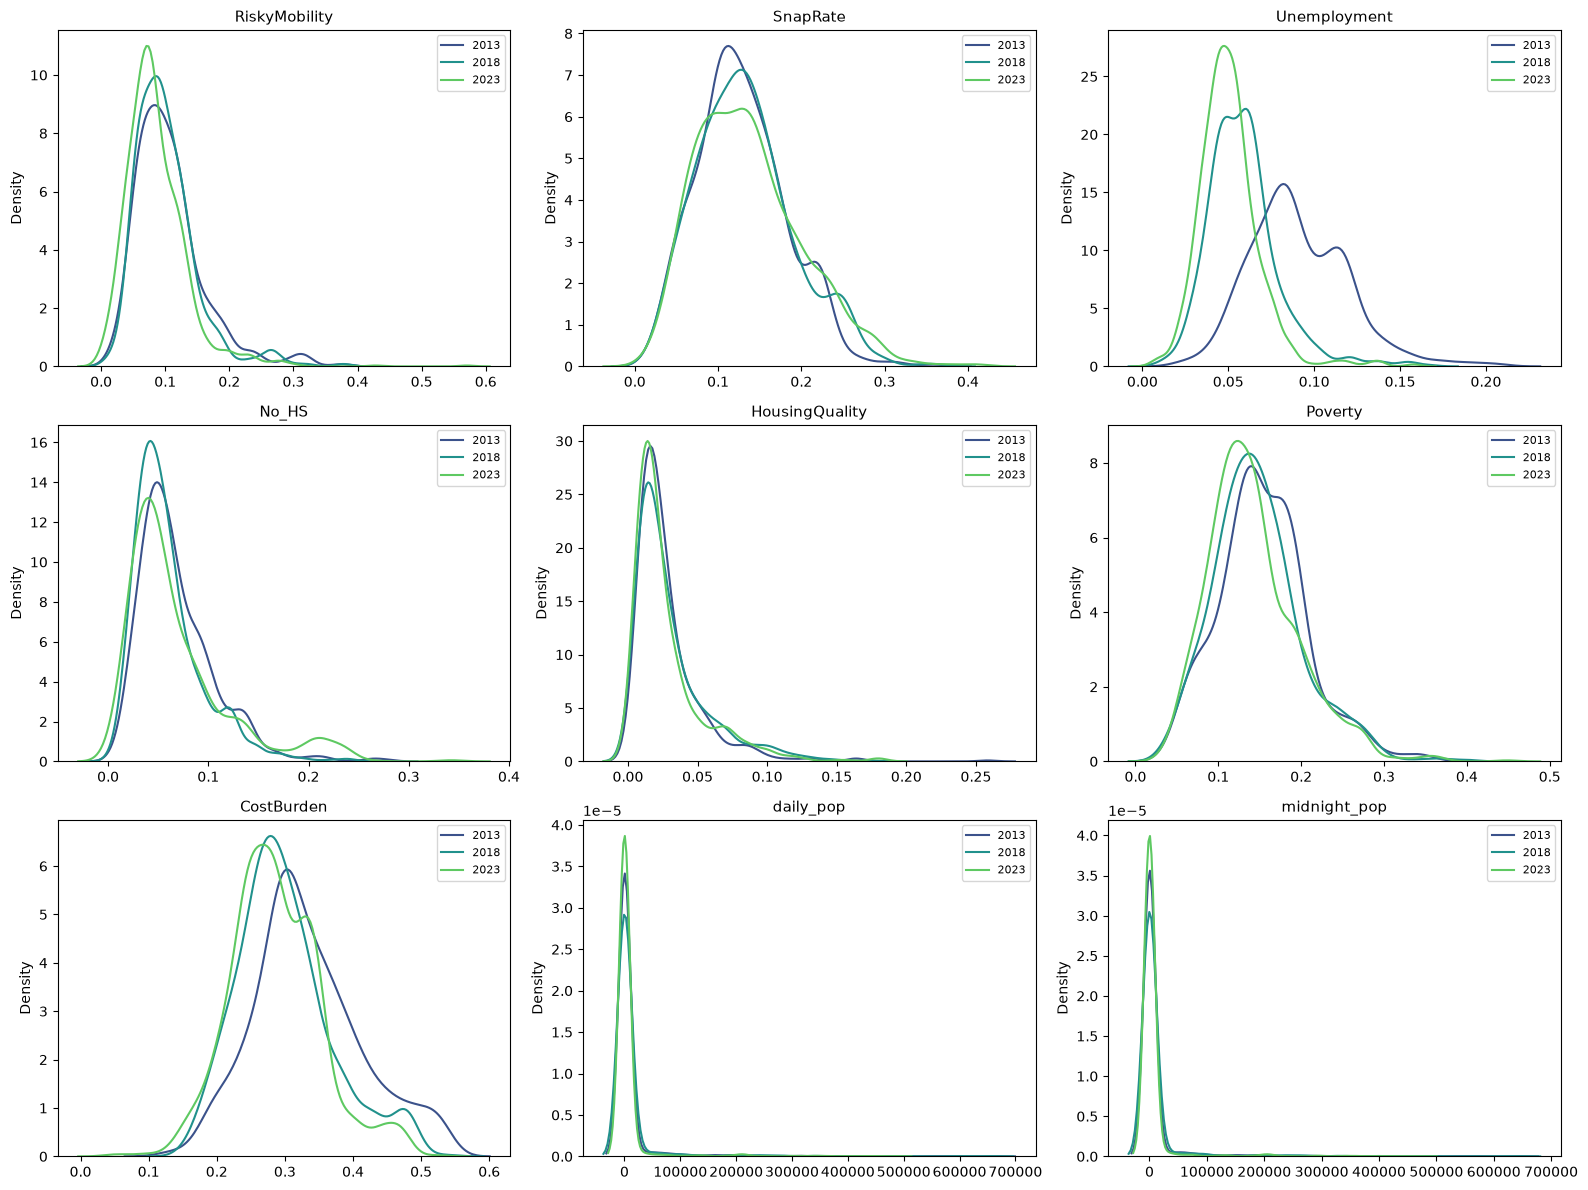

In [4]:
# Distribution of ACS variables across counties
%matplotlib inline

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
acs_vars = ["RiskyMobility", "SnapRate", "Unemployment", "No_HS", "HousingQuality", "Poverty", "CostBurden", "daily_pop", "midnight_pop"]
colors = sns.color_palette("viridis", 3)

for ax, var in zip(axes.flatten(), acs_vars):
    for i, yr in enumerate(sorted(df["year"].unique())):
        subset = df[df["year"] == yr][var].dropna()
        sns.kdeplot(subset, ax=ax, label=int(yr), color=colors[i], linewidth=1.5)
    ax.set_title(var, fontsize=11)
    ax.set_xlabel("")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

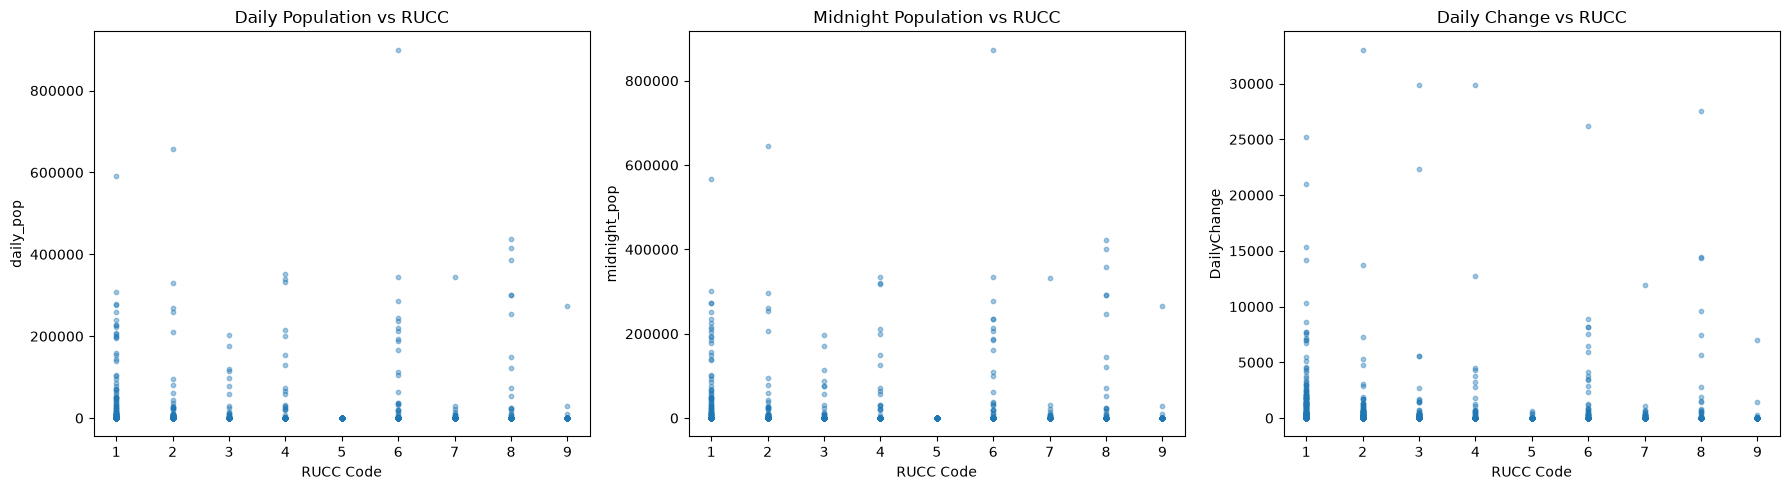

In [5]:
# Scatter: RUCC vs daily_pop / midnight_pop / DailyChange
%matplotlib inline

# ensure DailyChange exists in kernel state
if "DailyChange" not in county_data.columns:
    county_data["DailyChange"] = (county_data["daily_pop"] - county_data["midnight_pop"]).fillna(0)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

vars_to_plot = ["daily_pop", "midnight_pop", "DailyChange"]
titles = ["Daily Population vs RUCC", "Midnight Population vs RUCC", "Daily Change vs RUCC"]

for ax, var, title in zip(axes, vars_to_plot, titles):
    ax.scatter(county_data["rucc_code"], county_data[var], alpha=0.4, s=10)
    ax.set_xlabel("RUCC Code")
    ax.set_ylabel(var)
    ax.set_title(title)

plt.tight_layout()
plt.show()